In [26]:
import pandas as pd
import seaborn as sns
import matplotlib .pyplot as plt

print("All libraries are downloaded")

All libraries are downloaded


In [27]:
# Read the csv and print the head
df = pd.read_csv("../data/raw/properties_cleaned.csv")
df.head

<bound method NDFrame.head of                                              property_id property_type  \
0      https://immovlan.be/en/detail/residence/for-sa...         House   
1      https://immovlan.be/en/detail/apartment/for-sa...     Apartment   
2      https://immovlan.be/en/detail/duplex/for-sale/...     Apartment   
3      https://immovlan.be/en/detail/residence/for-sa...         House   
4      https://immovlan.be/en/detail/residence/for-sa...         House   
...                                                  ...           ...   
11496  https://immovlan.be/en/detail/apartment/for-sa...     Apartment   
11497  https://immovlan.be/en/detail/master-house/for...         House   
11498  https://immovlan.be/en/detail/residence/for-sa...         House   
11499  https://immovlan.be/en/detail/studio/for-sale/...     Apartment   
11500  https://immovlan.be/en/detail/residence/for-sa...         House   

      property_subtype     price price_type  living_area_m2  bedrooms  \
0       

In [28]:
# finding what type of data is there in our file
df.dtypes

# Finding only the numeric values
df.select_dtypes(include='number').columns



Index(['price', 'living_area_m2', 'bedrooms', 'bathrooms', 'postal_code',
       'latitude', 'longitude', 'building_year', 'furnished', 'has_garage',
       'parking_count', 'has_elevator', 'facades', 'floors_total',
       'has_garden', 'garden_area_m2', 'has_terrace', 'total_area_m2',
       'km_from_nearby_city', 'is_nearby_city_prestigious', 'floor_number'],
      dtype='str')

In [29]:
# Selecting the numeric value which will affect the output
numeric_columns = ['price','living_area_m2','bedrooms','bathrooms', 
       'building_year', 'furnished', 'has_garage',
       'parking_count', 'has_elevator', 'facades', 
       'has_garden',  'has_terrace', 
       'is_nearby_city_prestigious'
       ]
# Making a smaller dataframe with the above columns, dropping the rows which do not have price
# as it will directly affect our corelation
df_corr = df[numeric_columns].dropna(subset = ['price'])
df_corr.shape  #209 rows dropped as it did not have the data


(11292, 13)

In [30]:
#Finding the correlation between all the columns with price column
correlation = df_corr.corr()['price'].sort_values(ascending = False)
print(correlation)

price                         1.000000
living_area_m2                0.572237
bedrooms                      0.541780
bathrooms                     0.505394
facades                       0.240174
has_garden                    0.197984
has_terrace                   0.149165
is_nearby_city_prestigious    0.109676
building_year                 0.066840
furnished                    -0.001005
parking_count                -0.010533
has_elevator                 -0.031503
has_garage                         NaN
Name: price, dtype: float64


In [31]:
#Finding why has_garage comes to NaN
df_corr['has_garage'].value_counts(dropna= False)

# Because 'has_garage' has NaN values more than the half and also no 0 values are there
#there cannot be any correlation between this value and price, so we will drop this.

has_garage
NaN    6400
1.0    4892
Name: count, dtype: int64

In [32]:
# Removed has_garage
numeric_columns = ['price','living_area_m2','bedrooms','bathrooms', 
       'building_year', 'furnished',
       'parking_count', 'has_elevator', 'facades', 
       'has_garden',  'has_terrace', 
       'is_nearby_city_prestigious'
       ]
df_corr = df[numeric_columns].dropna(subset = ['price'])       
correlation = df_corr.corr()['price'].sort_values(ascending = False)
print(correlation)

price                         1.000000
living_area_m2                0.572237
bedrooms                      0.541780
bathrooms                     0.505394
facades                       0.240174
has_garden                    0.197984
has_terrace                   0.149165
is_nearby_city_prestigious    0.109676
building_year                 0.066840
furnished                    -0.001005
parking_count                -0.010533
has_elevator                 -0.031503
Name: price, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

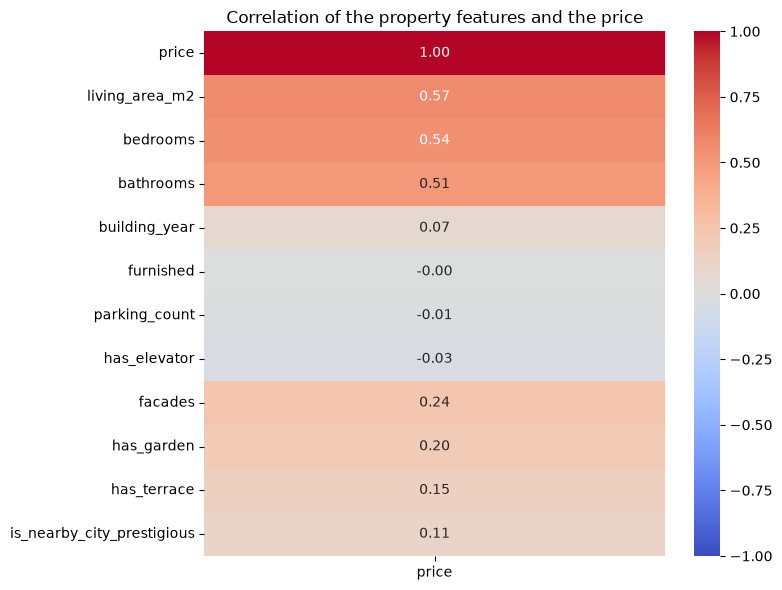

In [33]:
plt.figure(figsize=(8,6))  #size of the chart
sns.heatmap(
    df_corr.corr()[['price']],
    annot = True,        # show the number inside the boxes
    fmt = '.2f',         # round to 2 decimal places
    cmap = 'coolwarm',   # red for positive and blue for negative
    vmin = -1,           # goes from -1 to 1
    vmax = 1
)
plt.title("Correlation of the property features and the price")
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show

In [34]:
# "What are the least/most expensive municipalities in Belgium/Wallonia/Flanders? in terms of:
# price per m²
# average price
# median price
df['price_per_m2'] = df['price']/df ['living_area_m2'] # Creating a new column with the divided values
df[['city','price','living_area_m2','price_per_m2']].head(10) # Checking if the new column was created

,city,price,living_area_m2,price_per_m2
0,flemalle,550000.0,250.0,2200.000000
1,elsene,200000.0,57.0,3508.771930
2,tournai,189000.0,115.0,1643.478261
3,eksel,549000.0,399.0,1375.939850
4,la-roche-en-ardenne,330000.0,99.0,3333.333333
5,sint-lambrechts-woluwe,860000.0,240.0,3583.333333
6,chapelle-lez-herlaimont,194000.0,180.0,1077.777778
7,namur,650000.0,800.0,812.500000
8,durbuy,85000.0,34.0,2500.000000
9,binderveld,795000.0,232.0,3426.724138


In [35]:
city_stats = df.groupby('city').agg(
    avg_price = ('price', 'mean'),
    median_price = ('price','median'),
    avg_price_per_m2 = ('price_per_m2','mean'),
    count = ('price','count')
).reset_index()

# Cities with 5 properties
city_stats = city_stats[city_stats['count']>=5]  # Filtering with the count greater than 5
#city_val = city_val.reset_index(drop=True) # This will reset the numbers in the columns

city_stats.head(10)

,city,avg_price,median_price,avg_price_per_m2,count
2,aalst,459406.607843,325000.0,2512.816384,51
3,aalter,571550.642857,496000.0,2820.051904,14
14,aiseau-presles,222000.000000,199000.0,1521.617366,6
15,alken,456444.444444,450000.0,2054.086129,9
19,amay,208083.500000,199000.0,1744.854491,26
23,amel,365363.636364,293000.0,2986.959795,11
24,amonines,228100.000000,94000.0,1592.383107,5
27,andenne,271111.696429,240492.5,2121.367717,56
28,anderlecht,241599.375000,211000.0,2765.987004,160
29,anderlues,264399.933333,194900.0,1396.067165,15


In [36]:

print("Top 5 most expensive cities(Average Price)")
print(city_stats.nlargest(5,'avg_price')[['city','avg_price','count']])

print("\n5 least expensive cities(Average Price)")
print(city_stats.nsmallest(5,'avg_price')[['city','avg_price','count']])

Top 5 most expensive cities(Average Price)
              city     avg_price  count
345       eernegem  1.104500e+06      6
690   knokke-heist  1.093526e+06     36
689         knokke  1.009029e+06     34
1146       seneffe  9.873333e+05      6
1137       schilde  9.369151e+05      8

5 least expensive cities(Average Price)
                    city      avg_price  count
80               baileux   69975.000000      8
158             blaimont   87666.666667     30
554    hastiere-par-dela   88428.571429      7
1348              wasmes  107625.000000      8
823   marchienne-au-pont  119789.210526     19


In [37]:
flanders = df[df['region'] == 'Flanders']
wallonia = df[df['region'] == 'Wallonia']

In [38]:
def city_stats_by_region(region_df):
    stats = region_df.groupby('city').agg(
    avg_price = ('price', 'mean'),
    median_price = ('price','median'),
    avg_price_per_m2 = ('price_per_m2','mean'),
    count = ('price','count')
).reset_index()
    return stats[stats['count']>=5]

flanders_stats = city_stats_by_region(flanders)
wallonia_stats = city_stats_by_region(wallonia)


In [39]:
print("Top 5 most expensive cities(Average Price)")
print(flanders_stats.nlargest(5,'avg_price')[['city','avg_price','count']])

print("\n5 least expensive cities(Average Price)")
print(flanders_stats.nsmallest(5,'avg_price')[['city','avg_price','count']])

print("Top 5 most expensive cities(Average Price)")
print(wallonia_stats.nlargest(5,'avg_price')[['city','avg_price','count']])

print("\n5 least expensive cities(Average Price)")
print(wallonia_stats.nsmallest(5,'avg_price')[['city','avg_price','count']])

Top 5 most expensive cities(Average Price)
             city     avg_price  count
114      eernegem  1.104500e+06      6
217  knokke-heist  1.093526e+06     36
216        knokke  1.009029e+06     34
381       schilde  9.369151e+05      8
383       schoten  8.615000e+05      6

5 least expensive cities(Average Price)
             city      avg_price  count
458        wervik  187190.000000     20
170       herselt  194666.666667      6
459      westende  198257.692308     26
362        rekkem  199000.000000     11
332  oostrozebeke  206166.666667      6
Top 5 most expensive cities(Average Price)
        city      avg_price  count
746  seneffe  987333.333333      6
649     pecq  752800.000000     10
860   waimes  747888.888889      9
497    libin  738444.444444      9
874  warsage  733750.000000      8

5 least expensive cities(Average Price)
                   city      avg_price  count
56              baileux   69975.000000      8
103            blaimont   87666.666667     30
392   hast

In [40]:
print(wallonia_stats.nsmallest(5, 'avg_price')[['city', 'avg_price', 'count']])

                   city      avg_price  count
56              baileux   69975.000000      8
103            blaimont   87666.666667     30
392   hastiere-par-dela   88428.571429      7
875              wasmes  107625.000000      8
542  marchienne-au-pont  119789.210526     19


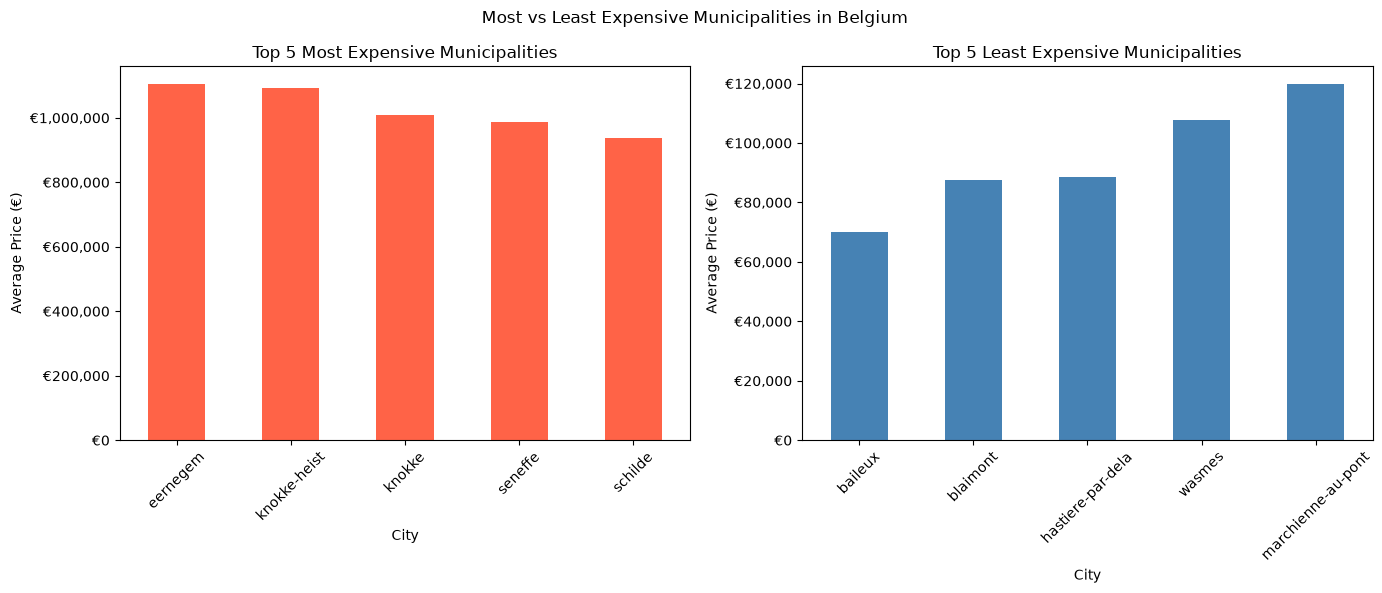

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Most expensive in Belgium
city_stats.nlargest(5, 'avg_price').plot(
    kind='bar', x='city', y='avg_price', 
    ax=axes[0], color='tomato', legend=False
)
axes[0].set_title('Top 5 Most Expensive Municipalities')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Average Price (€)')
axes[0].tick_params(axis='x', rotation=45)

# Least expensive in Belgium
city_stats.nsmallest(5, 'avg_price').plot(
    kind='bar', x='city', y='avg_price', 
    ax=axes[1], color='steelblue', legend=False
)
axes[1].set_title('Top 5 Least Expensive Municipalities')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Average Price (€)')
axes[1].tick_params(axis='x', rotation=45)

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
)
plt.suptitle('Most vs Least Expensive Municipalities in Belgium')
plt.tight_layout()
plt.savefig('../images/municipality_prices.png', dpi=150, bbox_inches='tight')
plt.show()

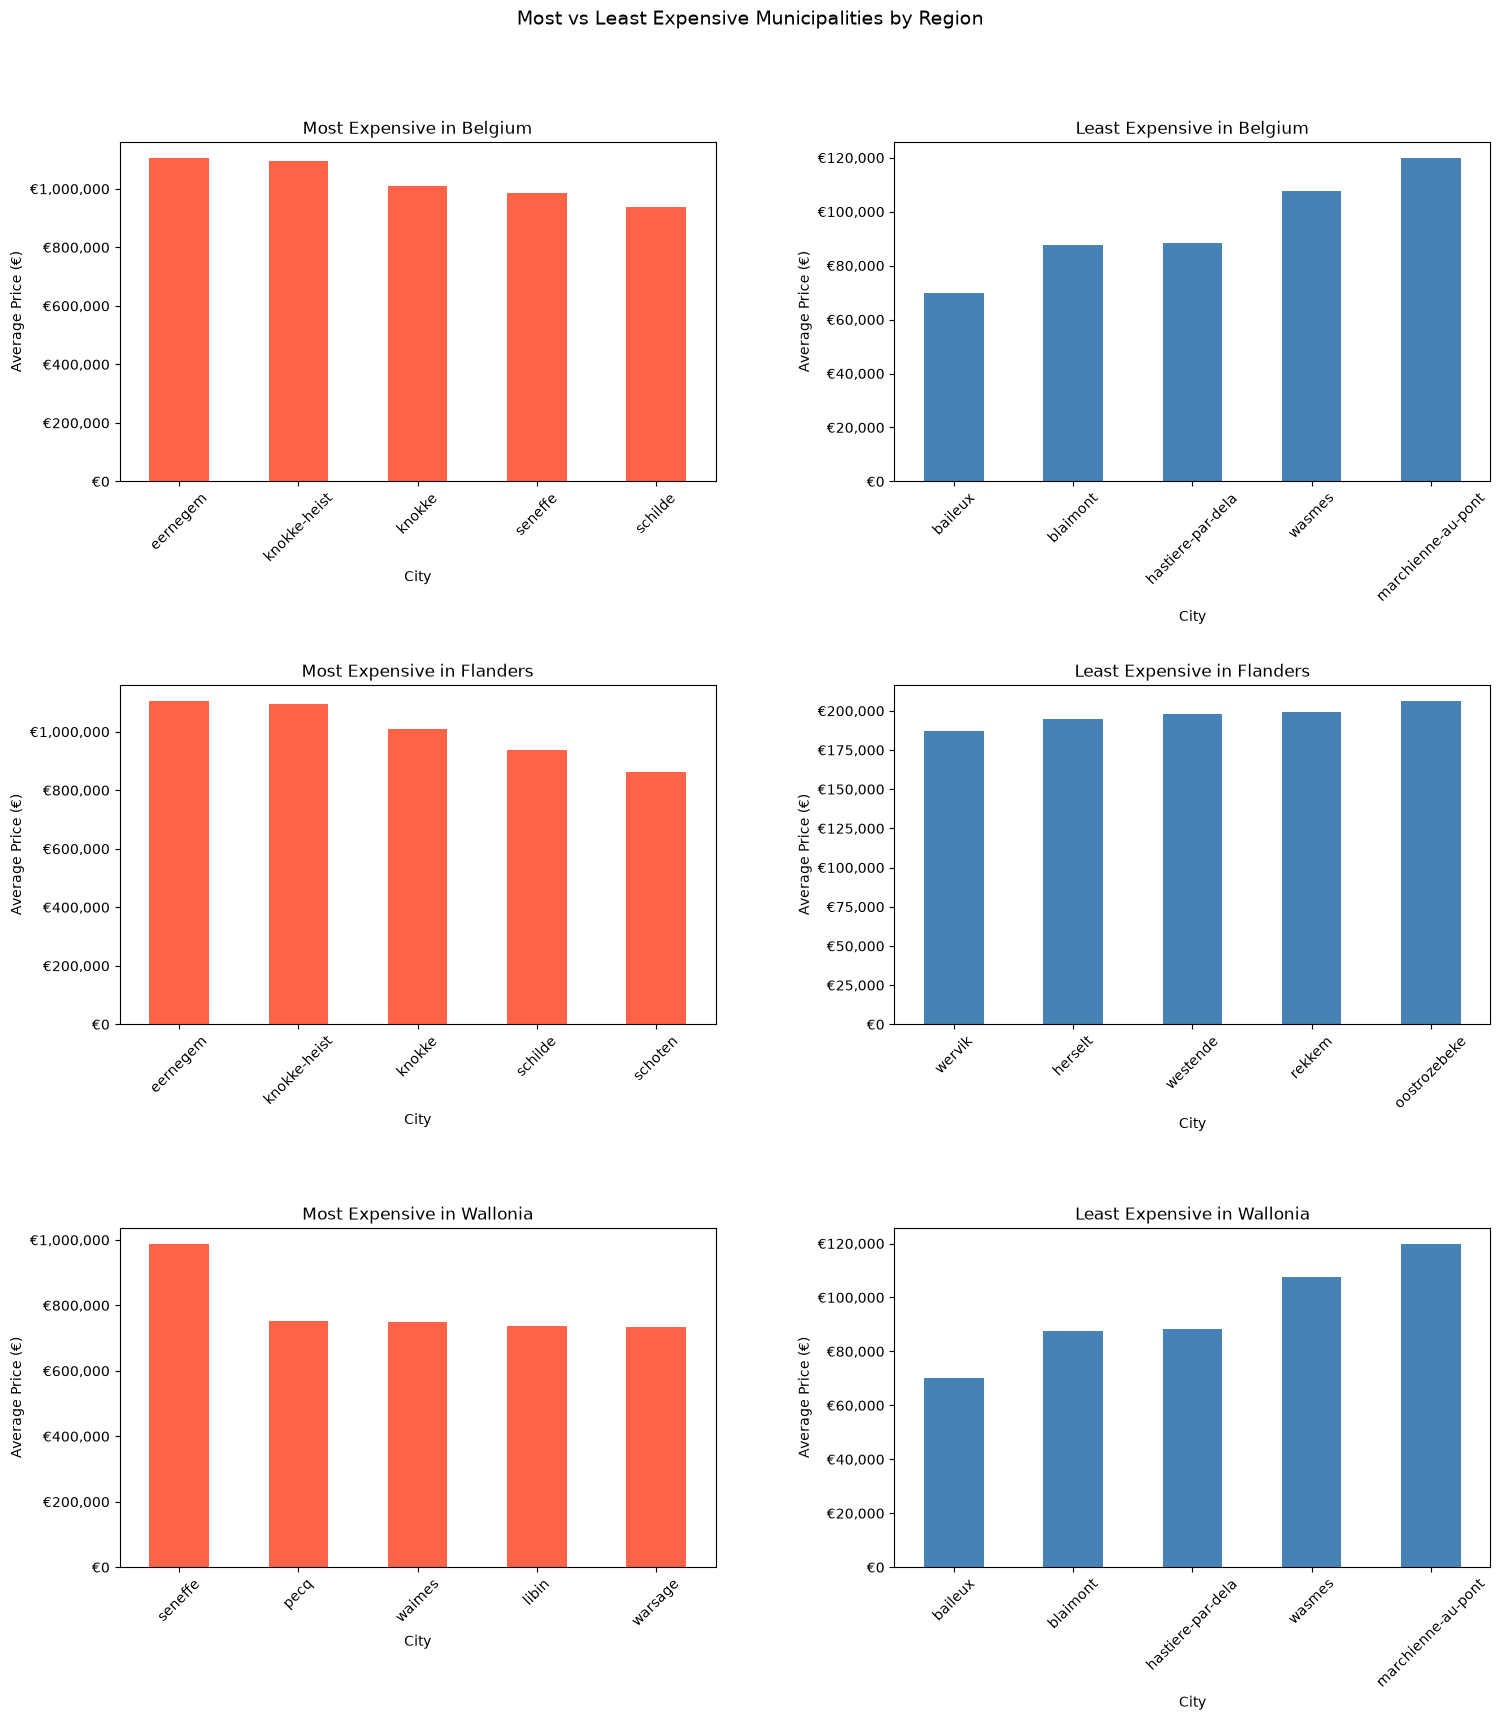

In [42]:
fig, axes = plt.subplots(3, 2, figsize= (16,18))
regions = [('Belgium',city_stats),
('Flanders',flanders_stats),
('Wallonia',wallonia_stats)
]
for i, (region_name, stats) in enumerate(regions):
    # Most Expensive
    stats.nlargest(5, 'avg_price').plot(kind='bar',x = 'city', y = 'avg_price', 
    ax = axes[i][0], color = 'tomato', legend=False
    )

    axes[i][0].set_title(f'Most Expensive in {region_name}')
    axes[i][0].set_xlabel('City')
    axes[i][0].set_ylabel('Average Price (€)')
    axes[i][0].tick_params(axis = 'x', rotation = 45)
    axes[i][0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    # Least Expensive
    stats.nsmallest(5, 'avg_price').plot(kind='bar',x = 'city', y = 'avg_price', 
    ax = axes[i][1], color = 'steelblue', legend=False
    )

    axes[i][1].set_title(f'Least Expensive in {region_name}')
    axes[i][1].set_xlabel('City')
    axes[i][1].set_ylabel('Average Price (€)')
    axes[i][1].tick_params(axis = 'x', rotation = 45)
    axes[i][1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    plt.suptitle('Most vs Least Expensive Municipalities by Region', fontsize = 14)
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    plt.savefig('../images/municipality_prices_by_region.png', dpi=150, bbox_inches='tight')
    plt.show


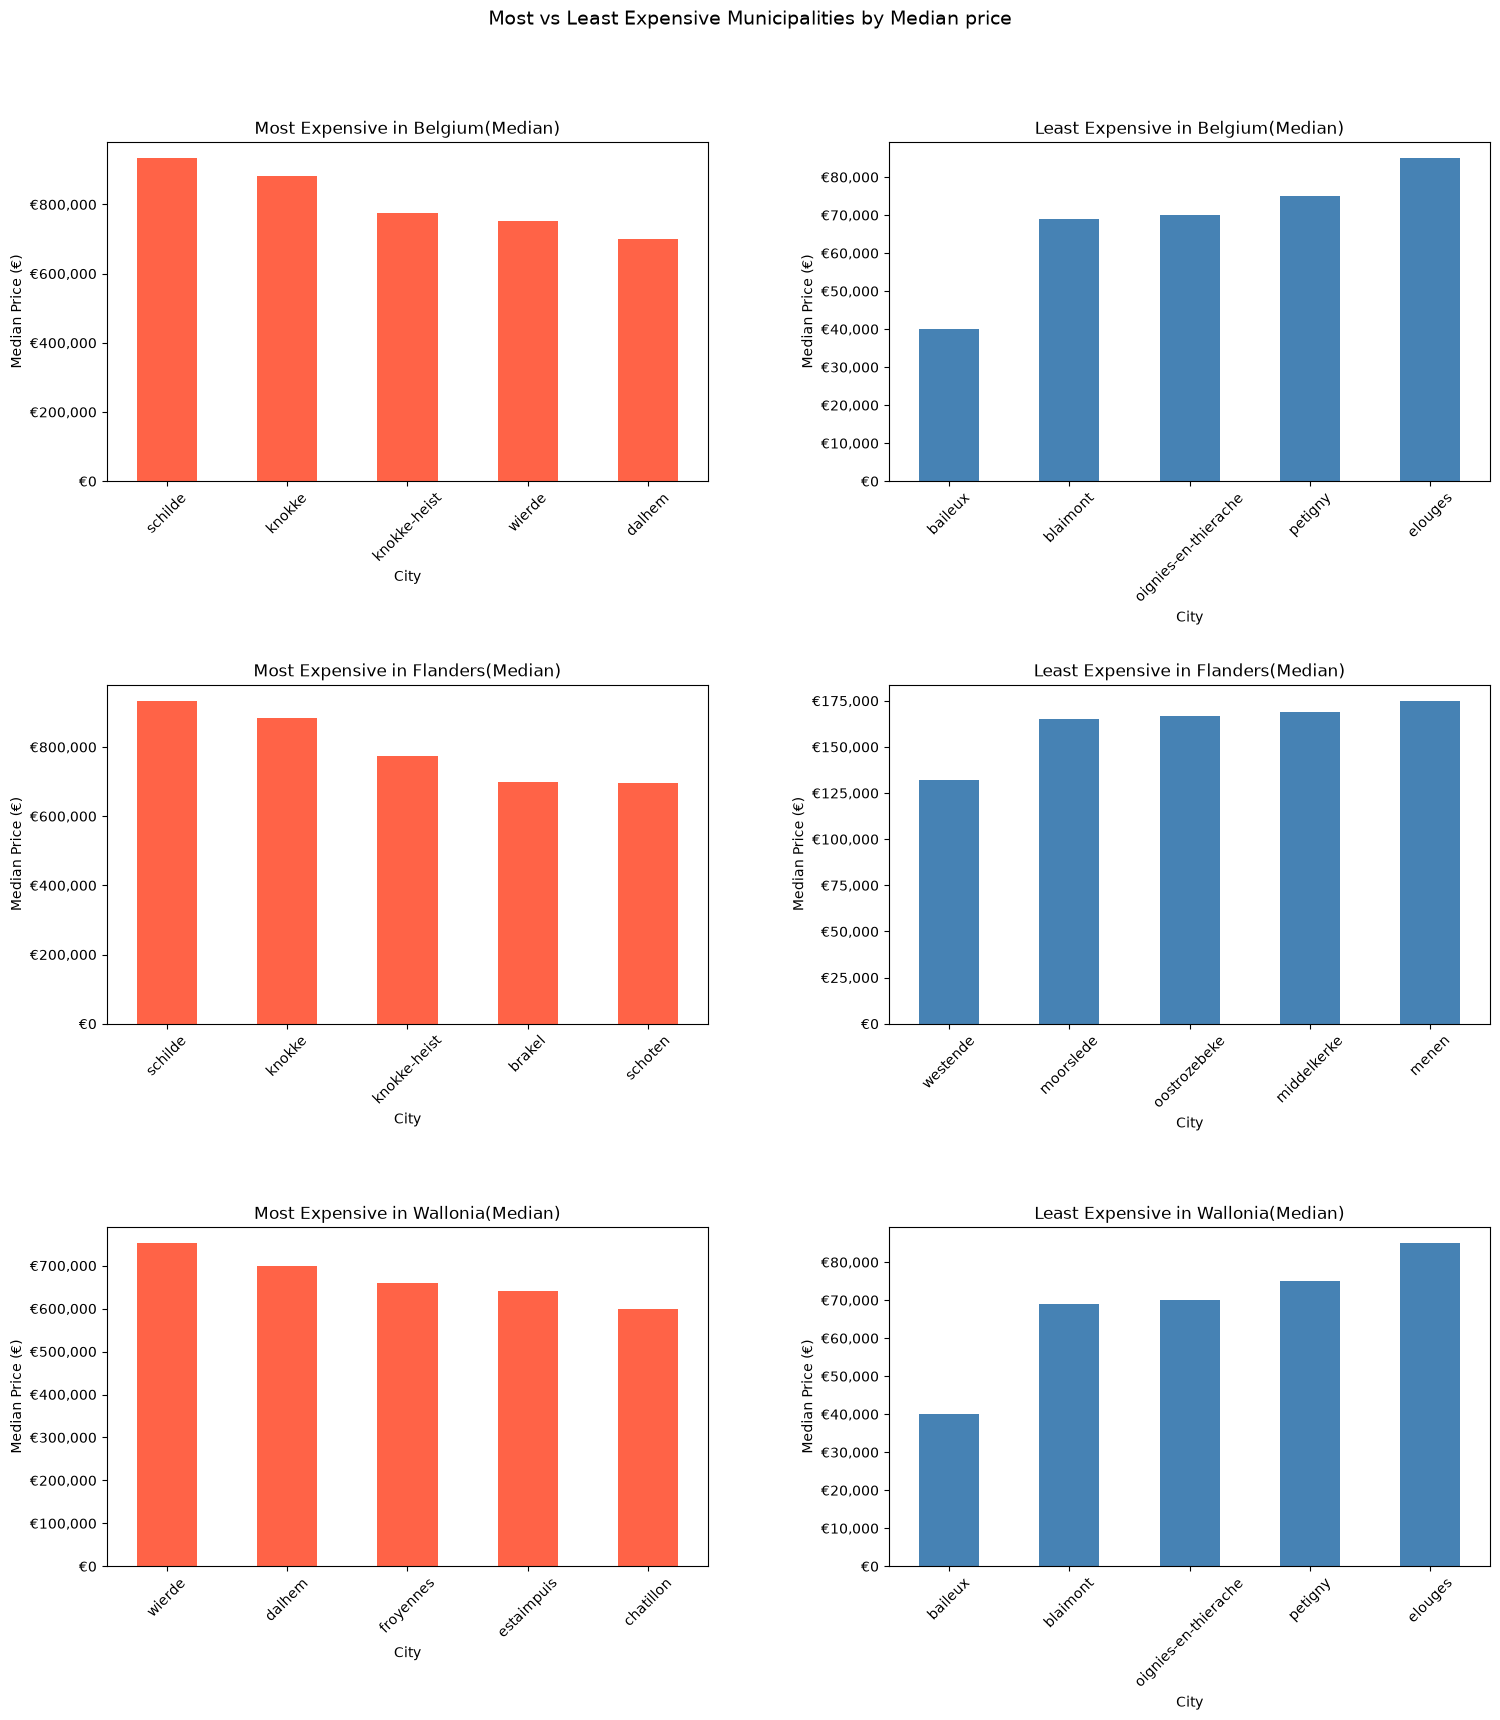

In [43]:
# Charts for median of the municipalities
fig, axes = plt.subplots(3, 2, figsize= (16,18))
regions = [('Belgium',city_stats),
('Flanders',flanders_stats),
('Wallonia',wallonia_stats)
]
for i, (region_name, stats) in enumerate(regions):
    # Most Expensive
    stats.nlargest(5, 'median_price').plot(kind='bar',x = 'city', y = 'median_price', 
    ax = axes[i][0], color = 'tomato', legend=False
    )

    axes[i][0].set_title(f'Most Expensive in {region_name}(Median)')
    axes[i][0].set_xlabel('City')
    axes[i][0].set_ylabel('Median Price (€)')
    axes[i][0].tick_params(axis = 'x', rotation = 45)
    axes[i][0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    # Least Expensive
    stats.nsmallest(5, 'median_price').plot(kind='bar',x = 'city', y = 'median_price', 
    ax = axes[i][1], color = 'steelblue', legend=False
    )

    axes[i][1].set_title(f'Least Expensive in {region_name}(Median)')
    axes[i][1].set_xlabel('City')
    axes[i][1].set_ylabel('Median Price (€)')
    axes[i][1].tick_params(axis = 'x', rotation = 45)
    axes[i][1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    plt.suptitle('Most vs Least Expensive Municipalities by Median price', fontsize = 14)
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    plt.savefig('../images/municipality_prices_by_region.png', dpi=150, bbox_inches='tight')
    plt.show


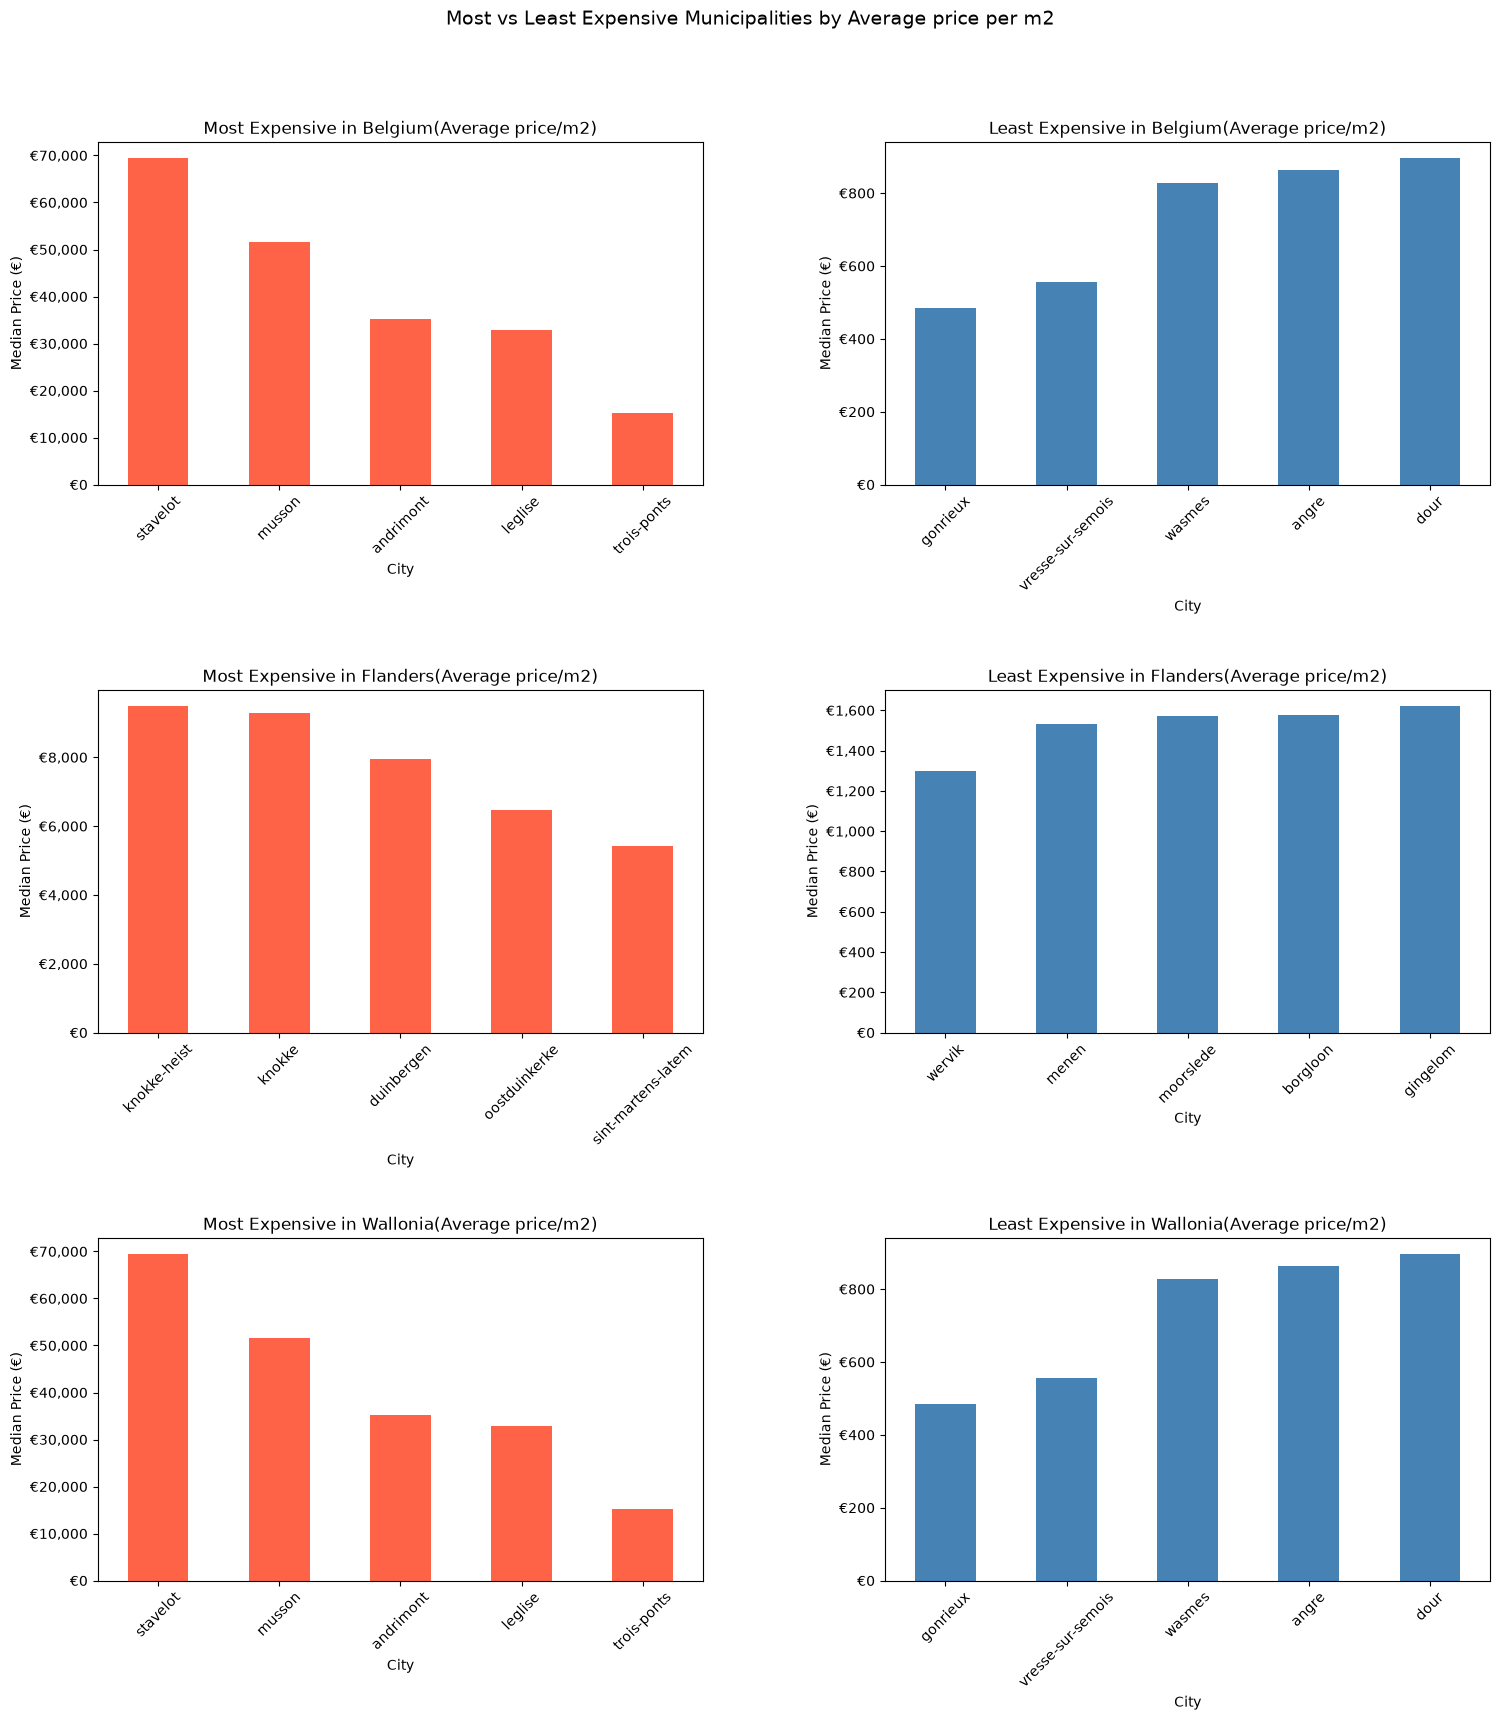

In [44]:
# Charts for price_per_m2 of the municipalities
fig, axes = plt.subplots(3, 2, figsize= (16,18))
regions = [('Belgium',city_stats),
('Flanders',flanders_stats),
('Wallonia',wallonia_stats)
]
for i, (region_name, stats) in enumerate(regions):
    # Most Expensive
    stats.nlargest(5, 'avg_price_per_m2').plot(kind='bar',x = 'city', y = 'avg_price_per_m2', 
    ax = axes[i][0], color = 'tomato', legend=False
    )

    axes[i][0].set_title(f'Most Expensive in {region_name}(Average price/m2)')
    axes[i][0].set_xlabel('City')
    axes[i][0].set_ylabel('Median Price (€)')
    axes[i][0].tick_params(axis = 'x', rotation = 45)
    axes[i][0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    # Least Expensive
    stats.nsmallest(5, 'avg_price_per_m2').plot(kind='bar',x = 'city', y = 'avg_price_per_m2', 
    ax = axes[i][1], color = 'steelblue', legend=False
    )

    axes[i][1].set_title(f'Least Expensive in {region_name}(Average price/m2)')
    axes[i][1].set_xlabel('City')
    axes[i][1].set_ylabel('Median Price (€)')
    axes[i][1].tick_params(axis = 'x', rotation = 45)
    axes[i][1].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
    )

    plt.suptitle('Most vs Least Expensive Municipalities by Average price per m2', fontsize = 14)
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    plt.savefig('../images/municipality_prices_by_region.png', dpi=150, bbox_inches='tight')
    plt.show


In [45]:
print(df[df['city'] == 'stavelot'][['city', 'price', 'living_area_m2', 'price_per_m2']])

           city      price  living_area_m2   price_per_m2
312    stavelot   466000.0             1.0  466000.000000
335    stavelot   515000.0           230.0    2239.130435
518    stavelot    69000.0            49.0    1408.163265
3341   stavelot   545000.0           249.0    2188.755020
4181   stavelot   275000.0           150.0    1833.333333
5250   stavelot  1490000.0           462.0    3225.108225
5269   stavelot   165000.0           133.0    1240.601504
9594   stavelot   145000.0             1.0  145000.000000
11352  stavelot   189000.0           154.0    1227.272727


In [46]:
df[df['province'].isin(['Brabant Wallon', 'Vlaams-Brabant'])].shape

(0, 35)